Test image range before processing: min = 0.0 , max = 1.0
Using unet_model without rescaling (input already normalized).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step


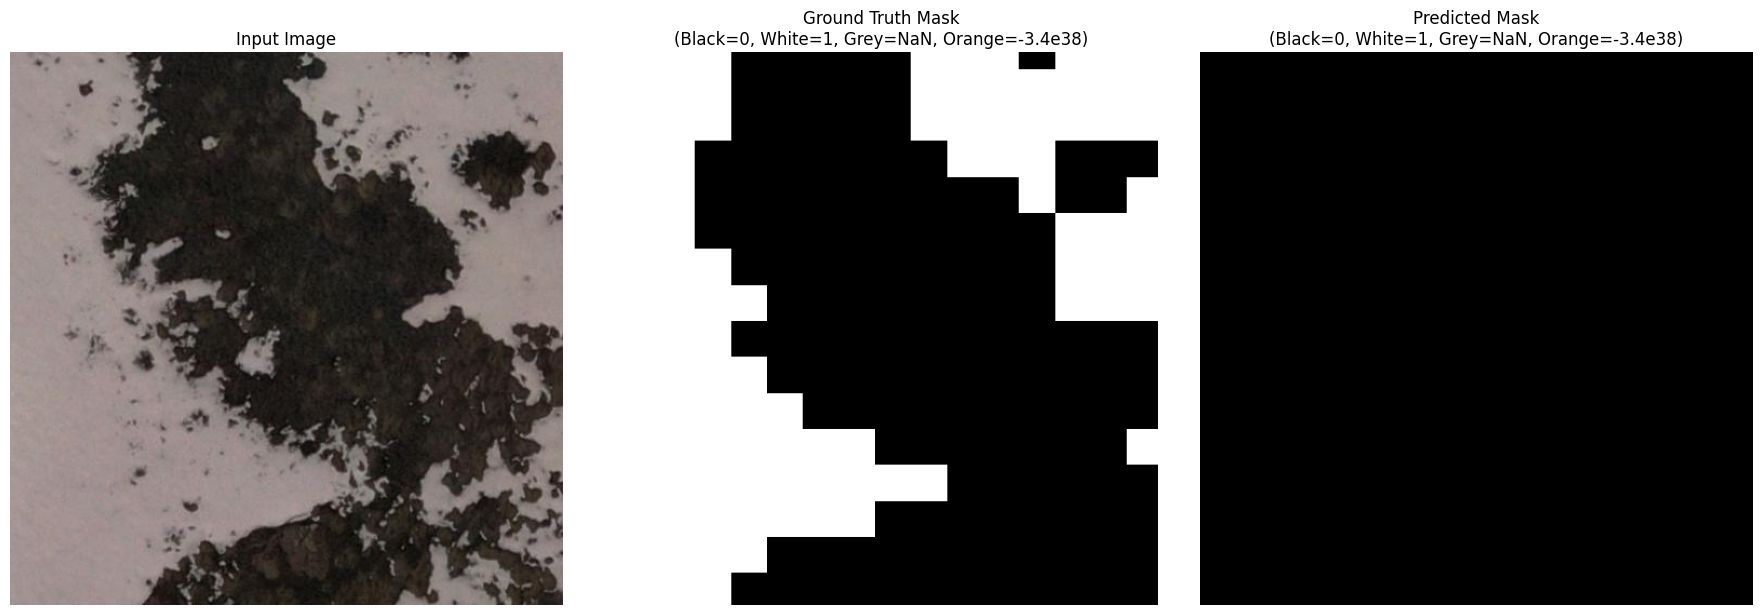

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.colors import ListedColormap, BoundaryNorm

# Optional: dice_coef if needed for model loading.
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# --- Define a helper function to map mask values ---
def map_mask(mask):
    """
    Maps a mask to discrete values:
      - 0.0 becomes 0 (black)
      - 1.0 becomes 1 (white)
      - NaN becomes 2 (grey)
      - -3.4e38 becomes 3 (orange)
    """
    mapped = np.full(mask.shape, -1, dtype=int)
    # Note: Order matters; we assume that NaNs and -3.4e38 are not also close to 0 or 1.
    mapped[np.isclose(mask, 0.0)] = 0
    mapped[np.isclose(mask, 1.0)] = 1
    mapped[np.isnan(mask)] = 2
    mapped[np.isclose(mask, -3.4e38, atol=1e-5)] = 3
    return mapped

# Define the discrete colormap.
cmap = ListedColormap(["black", "white", "grey", "orange"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# --- Set paths for test image and mask ---
test_img_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_1001_img.npy"
test_msk_path = test_img_path.replace("_img.npy", "_msk.npy")

# --- Load test image and mask ---
test_img = np.load(test_img_path)
test_msk = np.load(test_msk_path)

# --- Preprocess the test image ---
# Check if the image is channels-first (e.g., shape (channels, H, W)); if so, transpose it.
if test_img.ndim == 3:
    if test_img.shape[0] in [3, 4]:
        test_img = np.transpose(test_img, (1, 2, 0))  # Now shape becomes (H, W, channels)
# If the model expects 4 channels but the image has only 3, add an extra channel.
if test_img.shape[-1] == 3:
    extra_channel = np.ones((test_img.shape[0], test_img.shape[1], 1), dtype=test_img.dtype)
    test_img = np.concatenate([test_img, extra_channel], axis=-1)

# Print the test image range.
print("Test image range before processing: min =", test_img.min(), ", max =", test_img.max())

# --- For display, convert image to uint8 if necessary ---
if test_img.max() > 1.0:
    # Assume the image is in [0, 255]
    img_disp = np.clip(test_img, 0, 255).astype(np.uint8)
else:
    # If already normalized to [0,1], scale to 0-255 for display.
    img_disp = (test_img * 255).astype(np.uint8)

# --- Process the ground truth mask for visualization ---
# If mask shape is (1, H, W), squeeze to (H, W)
if test_msk.ndim == 3 and test_msk.shape[0] == 1:
    msk_disp = test_msk[0]
else:
    msk_disp = test_msk

# Map the ground truth mask using our custom function.
msk_mapped = map_mask(msk_disp)

# --- Load your trained model ---
# Update model_path to point to your saved model file.
model_path = r"C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\2025-02-04-16-33\Model_Data\unet_2025-02-04-16-33.keras"
# Load the full model. This model was compiled as Sequential([Rescaling(1./255), unet_model]).
full_model = tf.keras.models.load_model(model_path, custom_objects={"dice_coef": dice_coef})

# --- Determine which model to use for inference ---
# Our training pipeline wrapped the U-Net with a Rescaling layer. If your test image is in [0,255],
# you can use the full model as-is.
if test_img.max() > 1.0:
    inference_model = full_model
    print("Using full model with rescaling (input expected in [0,255]).")
else:
    # If your test image is already normalized to [0,1], then use the underlying U-Net.
    inference_model = full_model.layers[-1]
    print("Using unet_model without rescaling (input already normalized).")

# --- Prepare test image for prediction ---
# Ensure the model receives a 4D tensor: (batch_size, height, width, channels)
test_img_input = np.expand_dims(test_img, axis=0)

# --- Run prediction ---
pred_mask = inference_model.predict(test_img_input)[0]  # Expected shape: (512, 512, 1)

# Optionally, apply a threshold to convert predictions to binary.
threshold = 0.5
pred_mask_binary = (pred_mask >= threshold).astype(np.float32)

# Map the predicted mask using the same mapping.
pred_mapped = map_mask(pred_mask_binary)

# --- Visualize the input image, ground truth mask, and predicted mask ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_disp)
axes[0].set_title("Input Image")
axes[0].axis("off")

axes[1].imshow(msk_mapped, cmap=cmap, norm=norm)
axes[1].set_title("Ground Truth Mask\n(Black=0, White=1, Grey=NaN, Orange=-3.4e38)")
axes[1].axis("off")

axes[2].imshow(pred_mapped, cmap=cmap, norm=norm)
axes[2].set_title("Predicted Mask\n(Black=0, White=1, Grey=NaN, Orange=-3.4e38)")
axes[2].axis("off")

plt.tight_layout()
plt.show()
